In [1]:
import numpy as np
from matplotlib import pyplot as plt 
import time 
from tqdm import tqdm

import jax
import jax.numpy as jnp
    
from dataclasses import dataclass
#jax.config.update("jax_disable_jit", True)


In [2]:
import nambu_class as nmb
import Eilenberger_methods as eil
import system_state as sys_state
import run_computation as comp
import custom_optimizer as copt

In [ ]:
ntheta = 20
cutoff = 30 * eil.EilenbergerEvolution.get_bcs_ratio()
nw = 200

# Define the fine grid
fine_nw = 200
fine_cutoff = 1.0* eil.EilenbergerEvolution.get_bcs_ratio()

fine_nw = nw
fine_cutoff = cutoff

grid_parameters = {'omega_sampling': nw, 'theta_sampling': ntheta, 'cutoff': cutoff}
system_parameters = {'critical_temperature': 1.0, 'gap_symmetry' : 's', 'average_indices': (2,3)}
sigma_scatterings = {'Elastic': 10.0, 'Dynes': 5.0} # {'Dynes': 0.0, 'Elastic': 0.0}
sigma_scatterings = None

my_eil = eil.EilenbergerEvolution(grid_parameters, system_parameters, sigma_scatterings = sigma_scatterings)
print(my_eil.w_arr)
temperatures = jnp.linspace(0.1,1.2,10)
print(temperatures)

(1, 1)
52.916313
[-52.916313   -51.19696    -49.533127   -47.92303    -46.36493
 -44.857117   -43.397972   -41.985886   -40.619366   -39.296906
 -38.017067   -36.778477   -35.579777   -34.419674   -33.296913
 -32.210266   -31.158562   -30.140663   -29.155455   -28.20188
 -27.278893   -26.385494   -25.520727   -24.683638   -23.873331
 -23.088913   -22.329546   -21.594406   -20.882683   -20.19362
 -19.526459   -18.88048    -18.254986   -17.649294   -17.06274
 -16.494703   -15.944561   -15.41171    -14.895574   -14.395606
 -13.911245   -13.441982   -12.987298   -12.5467005  -12.1197195
 -11.70588    -11.304741   -10.915865   -10.538826   -10.173227
  -9.81866     -9.474745    -9.141107    -8.817386    -8.503226
  -8.198297    -7.902258    -7.6147914   -7.3355856   -7.064335
  -6.8007507   -6.544543    -6.2954345   -6.053155    -5.8174405
  -5.5880394   -5.3646984   -5.1471777   -4.935239    -4.728654
  -4.5272007   -4.3306584   -4.1388125   -3.951457    -3.7683864
  -3.589405    -3.414318

In [4]:
gap_list = []
#for temp in tqdm(temperatures):
gaps = comp.calculate_equilibrium(temp_list = temperatures, grid_parameters = grid_parameters, system_parameters = system_parameters, Q_list = [0], sigma_scatterings = sigma_scatterings)  
gap_list +=[gaps]



(6,)


In [5]:
print(gaps)

[1.5083026e+00-0.j 1.4955541e+00-0.j 1.4532722e+00-0.j 1.3489619e+00-0.j
 1.1612474e+00-0.j 8.1512737e-01-0.j 2.9090872e-02-0.j 7.3931634e-04-0.j
 9.1683473e-03-0.j 8.3704153e-04-0.j]


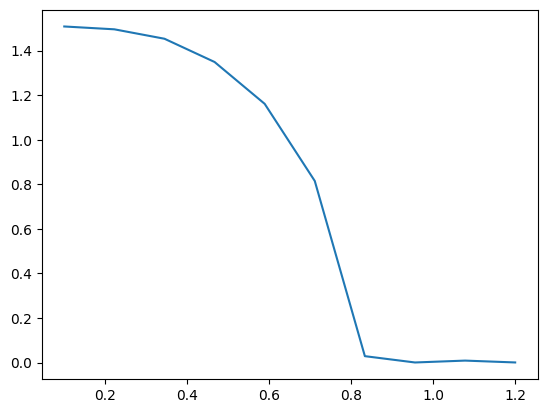

In [6]:
plt.plot(temperatures,jnp.abs(gaps))

In [7]:
jnp.sinh(1)
jnp.arcsinh(1)

Array(0.88137364, dtype=float32, weak_type=True)

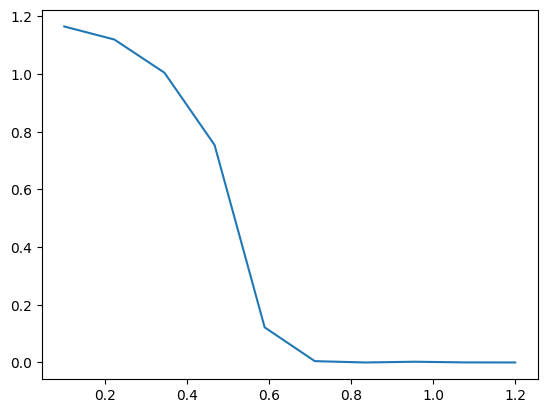

In [8]:
plt.plot(temperatures,jnp.abs(jnp.array(gaps[:])))